In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [179]:
dfs = []

for a in range(6):
    for b in range(1, 5):
        temp = f"RESEARCH DATA/indego_2{a}q{b}.csv"

        df = pd.read_csv(temp)
        dfs.append(df)
dfs.append(pd.read_csv("../../data/raw/indego_26q1.csv"))

C:\Users\davel\AppData\Local\Temp\ipykernel_24148\2522224116.py:7: DtypeWarning: Columns (0: bike_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(temp)
C:\Users\davel\AppData\Local\Temp\ipykernel_24148\2522224116.py:9: DtypeWarning: Columns (0: bike_id) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv("RESEARCH DATA/indego_26q1.csv"))


In [180]:
combo = pd.concat(dfs, ignore_index=True)

In [181]:
combo.isna().sum()

trip_id                     0
duration                    0
start_time                  0
end_time                    0
start_station               0
start_lat                 239
start_lon                 239
end_station                 0
end_lat                100125
end_lon                100125
bike_id                     0
plan_duration               0
trip_route_category         0
passholder_type          1712
bike_type                   0
dtype: int64

In [182]:
combo.head()

,trip_id,duration,start_time,end_time,start_station,start_lat,start_lon,end_station,end_lat,end_lon,bike_id,plan_duration,trip_route_category,passholder_type,bike_type
0,333803388,11,1/1/2020 0:13,1/1/2020 0:24,3049,39.945091,-75.142502,3072,39.934448,-75.145409,19794,30,One Way,Indego30,electric
1,333803387,28,1/1/2020 0:14,1/1/2020 0:42,3124,39.953621,-75.139542,3053,39.932308,-75.181541,19818,30,One Way,Indego30,electric
2,333803386,28,1/1/2020 0:14,1/1/2020 0:42,3124,39.953621,-75.139542,3053,39.932308,-75.181541,16510,30,One Way,Indego30,electric
3,333803385,21,1/1/2020 0:17,1/1/2020 0:38,3005,39.947330,-75.144028,3018,39.952728,-75.159790,16690,30,One Way,Indego30,electric
4,333803384,21,1/1/2020 0:17,1/1/2020 0:38,3005,39.947330,-75.144028,3018,39.952728,-75.159790,3423,30,One Way,Indego30,standard


In [183]:
combo['start_time'] = pd.to_datetime(combo['start_time'])
combo['end_time'] = pd.to_datetime(combo['end_time'])

In [184]:
combo.head()

,trip_id,duration,start_time,end_time,start_station,start_lat,start_lon,end_station,end_lat,end_lon,bike_id,plan_duration,trip_route_category,passholder_type,bike_type
0,333803388,11,2020-01-01 00:13:00,2020-01-01 00:24:00,3049,39.945091,-75.142502,3072,39.934448,-75.145409,19794,30,One Way,Indego30,electric
1,333803387,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,39.953621,-75.139542,3053,39.932308,-75.181541,19818,30,One Way,Indego30,electric
2,333803386,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,39.953621,-75.139542,3053,39.932308,-75.181541,16510,30,One Way,Indego30,electric
3,333803385,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,39.947330,-75.144028,3018,39.952728,-75.159790,16690,30,One Way,Indego30,electric
4,333803384,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,39.947330,-75.144028,3018,39.952728,-75.159790,3423,30,One Way,Indego30,standard


In [185]:
combo.shape

(6518098, 15)

In [186]:
combo.dtypes

trip_id                         int64
duration                        int64
start_time             datetime64[us]
end_time               datetime64[us]
start_station                   int64
start_lat                     float64
start_lon                     float64
end_station                     int64
end_lat                       float64
end_lon                       float64
bike_id                        object
plan_duration                   int64
trip_route_category               str
passholder_type                   str
bike_type                         str
dtype: object

In [187]:
combo['trip_route_category'].unique()

<StringArray>
['One Way', 'Round Trip']
Length: 2, dtype: str

In [188]:
combo['passholder_type'].value_counts()

passholder_type
Indego30      4129737
Indego365     1813410
Day Pass       438110
Walk-up        135116
IndegoFlex         13
Name: count, dtype: int64

In [189]:
combo['bike_type'].value_counts()

bike_type
standard    3296263
electric    3221835
Name: count, dtype: int64

In [190]:
trip = combo.copy()

In [191]:
trip.head()

,trip_id,duration,start_time,end_time,start_station,start_lat,start_lon,end_station,end_lat,end_lon,bike_id,plan_duration,trip_route_category,passholder_type,bike_type
0,333803388,11,2020-01-01 00:13:00,2020-01-01 00:24:00,3049,39.945091,-75.142502,3072,39.934448,-75.145409,19794,30,One Way,Indego30,electric
1,333803387,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,39.953621,-75.139542,3053,39.932308,-75.181541,19818,30,One Way,Indego30,electric
2,333803386,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,39.953621,-75.139542,3053,39.932308,-75.181541,16510,30,One Way,Indego30,electric
3,333803385,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,39.947330,-75.144028,3018,39.952728,-75.159790,16690,30,One Way,Indego30,electric
4,333803384,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,39.947330,-75.144028,3018,39.952728,-75.159790,3423,30,One Way,Indego30,standard


In [192]:
trip = trip.drop(['start_lat', 'start_lon', 'end_lat', 'end_lon', 'trip_id','bike_id'], axis=1)

In [193]:
trip.dtypes

duration                        int64
start_time             datetime64[us]
end_time               datetime64[us]
start_station                   int64
end_station                     int64
plan_duration                   int64
trip_route_category               str
passholder_type                   str
bike_type                         str
dtype: object

In [194]:
trip.head()

,duration,start_time,end_time,start_station,end_station,plan_duration,trip_route_category,passholder_type,bike_type
0,11,2020-01-01 00:13:00,2020-01-01 00:24:00,3049,3072,30,One Way,Indego30,electric
1,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,One Way,Indego30,electric
2,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,One Way,Indego30,electric
3,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,One Way,Indego30,electric
4,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,One Way,Indego30,standard


In [195]:
#trip.to_csv("trips.csv", index=False)

In [196]:
trip['st_year'] = trip['start_time'].dt.year
trip['st_month'] = trip['start_time'].dt.month
trip['st_day'] = trip['start_time'].dt.day
trip['st_hour'] = trip['start_time'].dt.hour
trip['st_minute'] = trip['start_time'].dt.minute
trip['end_year'] = trip['end_time'].dt.year
trip['end_month'] = trip['end_time'].dt.month
trip['end_day'] = trip['end_time'].dt.day
trip['end_hour'] = trip['end_time'].dt.hour
trip['end_minute'] = trip['end_time'].dt.minute

In [197]:
trip.head()

,duration,start_time,end_time,start_station,end_station,plan_duration,trip_route_category,passholder_type,bike_type,st_year,st_month,st_day,st_hour,st_minute,end_year,end_month,end_day,end_hour,end_minute
0,11,2020-01-01 00:13:00,2020-01-01 00:24:00,3049,3072,30,One Way,Indego30,electric,2020,1,1,0,13,2020,1,1,0,24
1,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,One Way,Indego30,electric,2020,1,1,0,14,2020,1,1,0,42
2,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,One Way,Indego30,electric,2020,1,1,0,14,2020,1,1,0,42
3,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,One Way,Indego30,electric,2020,1,1,0,17,2020,1,1,0,38
4,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,One Way,Indego30,standard,2020,1,1,0,17,2020,1,1,0,38


In [198]:
trip['bike_electric'] = (trip['bike_type'].str.lower() == 'electric').astype(int)

In [199]:
trip = trip.drop('bike_type', axis=1)

One-Hot Encode passholder type for ease of training

In [200]:
trip['passholder_type'].value_counts()

passholder_type
Indego30      4129737
Indego365     1813410
Day Pass       438110
Walk-up        135116
IndegoFlex         13
Name: count, dtype: int64

In [201]:
trip = trip[trip['passholder_type'] != 'IndegoFlex']

In [202]:
pass_dummies = pd.get_dummies(trip['passholder_type'], prefix='pass', dtype=int)

# 2. Attach these new boolean columns back to your main dataframe
trip = pd.concat([trip, pass_dummies], axis=1)

# 3. Drop the 'IndegoFlex' dummy column, plus the original 'passholder_type' column
# Note: Ensure the spelling and capitalization of 'IndegoFlex' exactly matches your data
trip = trip.drop(columns=['passholder_type'])

In [203]:
trip

,duration,start_time,end_time,start_station,end_station,plan_duration,trip_route_category,st_year,st_month,st_day,...,end_year,end_month,end_day,end_hour,end_minute,bike_electric,pass_Day Pass,pass_Indego30,pass_Indego365,pass_Walk-up
0,11,2020-01-01 00:13:00,2020-01-01 00:24:00,3049,3072,30,One Way,2020,1,1,...,2020,1,1,0,24,1,0,1,0,0
1,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,One Way,2020,1,1,...,2020,1,1,0,42,1,0,1,0,0
2,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,One Way,2020,1,1,...,2020,1,1,0,42,1,0,1,0,0
3,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,One Way,2020,1,1,...,2020,1,1,0,38,1,0,1,0,0
4,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,One Way,2020,1,1,...,2020,1,1,0,38,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6518093,15,2026-03-31 23:57:00,2026-04-01 00:12:00,3359,3100,365,One Way,2026,3,31,...,2026,4,1,0,12,1,0,0,1,0
6518094,3,2026-03-31 23:58:00,2026-04-01 00:01:00,3052,3304,365,One Way,2026,3,31,...,2026,4,1,0,1,1,0,0,1,0
6518095,13,2026-03-31 23:58:00,2026-04-01 00:11:00,3007,3361,30,One Way,2026,3,31,...,2026,4,1,0,11,1,0,1,0,0
6518096,13,2026-03-31 23:58:00,2026-04-01 00:11:00,3007,3361,365,One Way,2026,3,31,...,2026,4,1,0,11,1,0,0,1,0


Create boolean column for one-way trips, `trip_one_way`, and drop `trip_route_category` for easier storage

In [204]:
trip['trip_oneway'] = (trip['trip_route_category'].str.lower() == 'one way').astype(int)
trip = trip.drop('trip_route_category', axis=1)

In [205]:
trip

,duration,start_time,end_time,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,...,end_month,end_day,end_hour,end_minute,bike_electric,pass_Day Pass,pass_Indego30,pass_Indego365,pass_Walk-up,trip_oneway
0,11,2020-01-01 00:13:00,2020-01-01 00:24:00,3049,3072,30,2020,1,1,0,...,1,1,0,24,1,0,1,0,0,1
1,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,2020,1,1,0,...,1,1,0,42,1,0,1,0,0,1
2,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,2020,1,1,0,...,1,1,0,42,1,0,1,0,0,1
3,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,2020,1,1,0,...,1,1,0,38,1,0,1,0,0,1
4,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,2020,1,1,0,...,1,1,0,38,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6518093,15,2026-03-31 23:57:00,2026-04-01 00:12:00,3359,3100,365,2026,3,31,23,...,4,1,0,12,1,0,0,1,0,1
6518094,3,2026-03-31 23:58:00,2026-04-01 00:01:00,3052,3304,365,2026,3,31,23,...,4,1,0,1,1,0,0,1,0,1
6518095,13,2026-03-31 23:58:00,2026-04-01 00:11:00,3007,3361,30,2026,3,31,23,...,4,1,0,11,1,0,1,0,0,1
6518096,13,2026-03-31 23:58:00,2026-04-01 00:11:00,3007,3361,365,2026,3,31,23,...,4,1,0,11,1,0,0,1,0,1


In [206]:
trip.dtypes

duration                   int64
start_time        datetime64[us]
end_time          datetime64[us]
start_station              int64
end_station                int64
plan_duration              int64
st_year                    int32
st_month                   int32
st_day                     int32
st_hour                    int32
st_minute                  int32
end_year                   int32
end_month                  int32
end_day                    int32
end_hour                   int32
end_minute                 int32
bike_electric              int64
pass_Day Pass              int64
pass_Indego30              int64
pass_Indego365             int64
pass_Walk-up               int64
trip_oneway                int64
dtype: object

Rename columns to create uniformity within names

In [207]:
rename_col = {
    'pass_Day Pass': 'pass_daypass',
    'pass_Indego365': 'pass_indego365',
    'pass_Indego30': 'pass_indego30',
    'pass_Walk-up': 'pass_walkup',
}
trip = trip.rename(columns=rename_col)

In [208]:
trip

,duration,start_time,end_time,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,...,end_month,end_day,end_hour,end_minute,bike_electric,pass_daypass,pass_indego30,pass_indego365,pass_walkup,trip_oneway
0,11,2020-01-01 00:13:00,2020-01-01 00:24:00,3049,3072,30,2020,1,1,0,...,1,1,0,24,1,0,1,0,0,1
1,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,2020,1,1,0,...,1,1,0,42,1,0,1,0,0,1
2,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,2020,1,1,0,...,1,1,0,42,1,0,1,0,0,1
3,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,2020,1,1,0,...,1,1,0,38,1,0,1,0,0,1
4,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,2020,1,1,0,...,1,1,0,38,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6518093,15,2026-03-31 23:57:00,2026-04-01 00:12:00,3359,3100,365,2026,3,31,23,...,4,1,0,12,1,0,0,1,0,1
6518094,3,2026-03-31 23:58:00,2026-04-01 00:01:00,3052,3304,365,2026,3,31,23,...,4,1,0,1,1,0,0,1,0,1
6518095,13,2026-03-31 23:58:00,2026-04-01 00:11:00,3007,3361,30,2026,3,31,23,...,4,1,0,11,1,0,1,0,0,1
6518096,13,2026-03-31 23:58:00,2026-04-01 00:11:00,3007,3361,365,2026,3,31,23,...,4,1,0,11,1,0,0,1,0,1


Drop trips that are 1 minute long, and that are outside the 99 percentile.
This just slims down the trips that are negligible to the model, because who can ride a bike from one station to another in 1 minute? Also, included in the data dictionary from Indego, trip lengths are capped at 24 hours (1440 minutes), so those extreme values can be removed.

After this dropping, the data went from ~6.52 million entries to 6.28 million. While dropping ~ 240,000 entries may seem like a lot,  96.4% of the data still remains. Less than 4% of entries were removed, and it makes the data a lot cleaner when working with it.

In [209]:
trip = trip[trip['duration'] <= trip['duration'].quantile(0.99)]


In [210]:
trip = trip[trip['duration'] != 1]

In [211]:
trip = trip.drop(['start_time','end_time'], axis=1)

In [212]:
trip

,duration,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,st_minute,end_year,end_month,end_day,end_hour,end_minute,bike_electric,pass_daypass,pass_indego30,pass_indego365,pass_walkup,trip_oneway
0,11,3049,3072,30,2020,1,1,0,13,2020,1,1,0,24,1,0,1,0,0,1
1,28,3124,3053,30,2020,1,1,0,14,2020,1,1,0,42,1,0,1,0,0,1
2,28,3124,3053,30,2020,1,1,0,14,2020,1,1,0,42,1,0,1,0,0,1
3,21,3005,3018,30,2020,1,1,0,17,2020,1,1,0,38,1,0,1,0,0,1
4,21,3005,3018,30,2020,1,1,0,17,2020,1,1,0,38,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6518093,15,3359,3100,365,2026,3,31,23,57,2026,4,1,0,12,1,0,0,1,0,1
6518094,3,3052,3304,365,2026,3,31,23,58,2026,4,1,0,1,1,0,0,1,0,1
6518095,13,3007,3361,30,2026,3,31,23,58,2026,4,1,0,11,1,0,1,0,0,1
6518096,13,3007,3361,365,2026,3,31,23,58,2026,4,1,0,11,1,0,0,1,0,1


Let's look at a distribution of the trip duration to see what the most common trip lengths are.

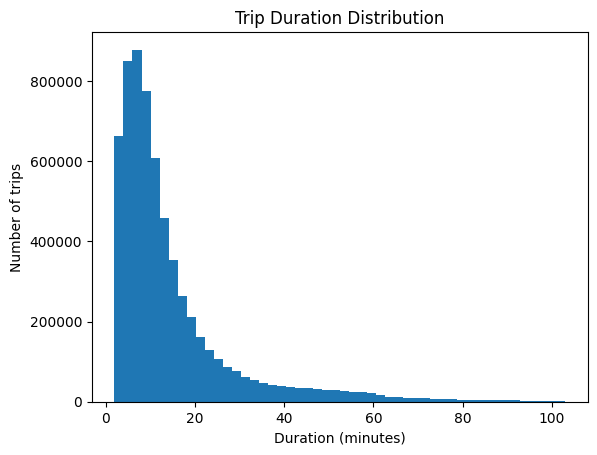

In [213]:
plt.figure()
plt.hist(trip["duration"], bins=50)
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of trips")
plt.title("Trip Duration Distribution")
plt.show()

In [214]:
trip

,duration,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,st_minute,end_year,end_month,end_day,end_hour,end_minute,bike_electric,pass_daypass,pass_indego30,pass_indego365,pass_walkup,trip_oneway
0,11,3049,3072,30,2020,1,1,0,13,2020,1,1,0,24,1,0,1,0,0,1
1,28,3124,3053,30,2020,1,1,0,14,2020,1,1,0,42,1,0,1,0,0,1
2,28,3124,3053,30,2020,1,1,0,14,2020,1,1,0,42,1,0,1,0,0,1
3,21,3005,3018,30,2020,1,1,0,17,2020,1,1,0,38,1,0,1,0,0,1
4,21,3005,3018,30,2020,1,1,0,17,2020,1,1,0,38,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6518093,15,3359,3100,365,2026,3,31,23,57,2026,4,1,0,12,1,0,0,1,0,1
6518094,3,3052,3304,365,2026,3,31,23,58,2026,4,1,0,1,1,0,0,1,0,1
6518095,13,3007,3361,30,2026,3,31,23,58,2026,4,1,0,11,1,0,1,0,0,1
6518096,13,3007,3361,365,2026,3,31,23,58,2026,4,1,0,11,1,0,0,1,0,1


A bit of verification, check the NaN values in the data set

In [215]:
trip.isna().sum()

duration          0
start_station     0
end_station       0
plan_duration     0
st_year           0
st_month          0
st_day            0
st_hour           0
st_minute         0
end_year          0
end_month         0
end_day           0
end_hour          0
end_minute        0
bike_electric     0
pass_daypass      0
pass_indego30     0
pass_indego365    0
pass_walkup       0
trip_oneway       0
dtype: int64

... none? That's... a lot of complete data. Check the dtypes to make sure all the columns are filled with the right type of data.

In [216]:
trip.dtypes

duration          int64
start_station     int64
end_station       int64
plan_duration     int64
st_year           int32
st_month          int32
st_day            int32
st_hour           int32
st_minute         int32
end_year          int32
end_month         int32
end_day           int32
end_hour          int32
end_minute        int32
bike_electric     int64
pass_daypass      int64
pass_indego30     int64
pass_indego365    int64
pass_walkup       int64
trip_oneway       int64
dtype: object

Okay then. This is a lot of data.

Since I am not storing massive numbers, I am going to change the data type for the 'boolean' categories into an `int8` or an `int16`.

This gives me a lot less bits to encode when uploading this to GitHub.

In [219]:
columns_to_int8 = [
    'st_month', 'st_day', 'st_hour', 'st_minute',
    'end_month', 'end_day', 'end_hour', 'end_minute',
    'bike_electric', 'pass_daypass', 'pass_indego30',
    'pass_indego365', 'pass_walkup', 'trip_oneway'
]

for col in columns_to_int8:
    trip[col] = trip[col].astype('int8')

Check to make sure it worked properly

In [220]:
trip.dtypes

duration          int64
start_station     int64
end_station       int64
plan_duration     int64
st_year           int32
st_month           int8
st_day             int8
st_hour            int8
st_minute          int8
end_year          int32
end_month          int8
end_day            int8
end_hour           int8
end_minute         int8
bike_electric      int8
pass_daypass       int8
pass_indego30      int8
pass_indego365     int8
pass_walkup        int8
trip_oneway        int8
dtype: object

Now, I want to create a numerical column for the day of the week, where `0 = Monday`, `1 = Tuesday`, etc. so that I can use this for modeling

In [221]:
# Create the temporary date format again
temp_dates = pd.to_datetime(trip[['st_year', 'st_month', 'st_day']].rename(columns={
    'st_year': 'year', 'st_month': 'month', 'st_day': 'day'
}))

# Output a single column with integers 0-6
trip['day_of_week'] = temp_dates.dt.dayofweek.astype('int8')

Add a boolean column for `is_weekend`. This column may be redundant, so may need to drop it later. There is a VERY clear correlation with this column and the `day_of_week` column.

In [222]:
trip['is_weekend'] = (trip['day_of_week'] >= 5).astype('int8')

In [223]:
trip.dtypes

duration          int64
start_station     int64
end_station       int64
plan_duration     int64
st_year           int32
st_month           int8
st_day             int8
st_hour            int8
st_minute          int8
end_year          int32
end_month          int8
end_day            int8
end_hour           int8
end_minute         int8
bike_electric      int8
pass_daypass       int8
pass_indego30      int8
pass_indego365     int8
pass_walkup        int8
trip_oneway        int8
day_of_week        int8
is_weekend         int8
dtype: object

Because this data will be used to train a GNN, cyclic features for repeating patterns, e.g. hours of the day, days of the week, months of the year, are related. Encoding hour, day, and month using cyclic features preserves the continuous loop of time, where Sunday is next to Monday and 23:00 is next to 00:00, instead of being the furthest thing apart as possible.

In [224]:
trip['st_hr_sin'] = np.sin(2 * np.pi * trip['st_hour'] / 24)
trip['st_hr_cos'] = np.cos(2 * np.pi * trip['st_hour'] / 24)

In [225]:
trip['st_day_sin'] = np.sin(2 * np.pi * trip['st_hour'] / 7)
trip['st_day_cos'] = np.cos(2 * np.pi * trip['st_hour'] / 7)

In [226]:
trip['st_yr_sin'] = np.sin(2 * np.pi * trip['st_hour'] / 12)
trip['st_yr_cos'] = np.cos(2 * np.pi * trip['st_hour'] / 12)

In [227]:
trip.dtypes

duration            int64
start_station       int64
end_station         int64
plan_duration       int64
st_year             int32
st_month             int8
st_day               int8
st_hour              int8
st_minute            int8
end_year            int32
end_month            int8
end_day              int8
end_hour             int8
end_minute           int8
bike_electric        int8
pass_daypass         int8
pass_indego30        int8
pass_indego365       int8
pass_walkup          int8
trip_oneway          int8
day_of_week          int8
is_weekend           int8
st_hr_sin         float64
st_hr_cos         float64
st_day_sin        float64
st_day_cos        float64
st_yr_sin         float64
st_yr_cos         float64
dtype: object

In [228]:
trip.head()

,duration,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,st_minute,end_year,...,pass_walkup,trip_oneway,day_of_week,is_weekend,st_hr_sin,st_hr_cos,st_day_sin,st_day_cos,st_yr_sin,st_yr_cos
0,11,3049,3072,30,2020,1,1,0,13,2020,...,0,1,2,0,0.0,1.0,0.0,1.0,0.0,1.0
1,28,3124,3053,30,2020,1,1,0,14,2020,...,0,1,2,0,0.0,1.0,0.0,1.0,0.0,1.0
2,28,3124,3053,30,2020,1,1,0,14,2020,...,0,1,2,0,0.0,1.0,0.0,1.0,0.0,1.0
3,21,3005,3018,30,2020,1,1,0,17,2020,...,0,1,2,0,0.0,1.0,0.0,1.0,0.0,1.0
4,21,3005,3018,30,2020,1,1,0,17,2020,...,0,1,2,0,0.0,1.0,0.0,1.0,0.0,1.0


In [229]:
trip.to_csv("trips.csv", index=False)

In [230]:
trip.info(memory_usage = 'deep')

<class 'pandas.DataFrame'>
Index: 6280562 entries, 0 to 6518097
Data columns (total 28 columns):
 #   Column          Dtype  
---  ------          -----  
 0   duration        int64  
 1   start_station   int64  
 2   end_station     int64  
 3   plan_duration   int64  
 4   st_year         int32  
 5   st_month        int8   
 6   st_day          int8   
 7   st_hour         int8   
 8   st_minute       int8   
 9   end_year        int32  
 10  end_month       int8   
 11  end_day         int8   
 12  end_hour        int8   
 13  end_minute      int8   
 14  bike_electric   int8   
 15  pass_daypass    int8   
 16  pass_indego30   int8   
 17  pass_indego365  int8   
 18  pass_walkup     int8   
 19  trip_oneway     int8   
 20  day_of_week     int8   
 21  is_weekend      int8   
 22  st_hr_sin       float64
 23  st_hr_cos       float64
 24  st_day_sin      float64
 25  st_day_cos      float64
 26  st_yr_sin       float64
 27  st_yr_cos       float64
dtypes: float64(6), int32(2), int

# COME BACK TO STORAGE OF TRIPS

In [233]:
#trip.to_parquet("trips.parquet", index=False)

In [232]:
import pandas as pd
import pyarrow as pa

print("pandas:", pd.__version__)
print("pyarrow:", pa.__version__)

pandas: 3.0.3
pyarrow: 24.0.0


In [235]:
# Load the trips.csv dataset
trips_df = pd.read_csv('../../data/processed/trips.csv')

# Randomly sample 2000 rows from the trips_df
# Using random_state for reproducibility
trips_sampled = trips_df.sample(n=2000, random_state=42)

print(f"Original trips_df shape: {trips_df.shape}")
print(f"Sampled trips_df shape: {trips_sampled.shape}")

# Display the first 5 rows of the sampled data
display(trips_sampled.head())

Original trips_df shape: (6280562, 28)
Sampled trips_df shape: (2000, 28)


,duration,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,st_minute,end_year,...,pass_walkup,trip_oneway,day_of_week,is_weekend,st_hr_sin,st_hr_cos,st_day_sin,st_day_cos,st_yr_sin,st_yr_cos
1140539,16,3018,3056,30,2021,8,12,15,17,2021,...,0,1,3,0,-0.707107,-0.707107,0.781831,0.623490,1.000000,1.194340e-15
5124057,9,3201,3102,1,2025,5,14,16,24,2025,...,1,1,2,0,-0.866025,-0.500000,0.974928,-0.222521,0.866025,-5.000000e-01
1204233,12,3238,3064,365,2021,9,2,19,59,2021,...,0,1,3,0,-0.965926,0.258819,-0.974928,-0.222521,-0.500000,-8.660254e-01
6221144,12,3025,3373,30,2026,3,14,10,6,2026,...,0,1,5,1,0.500000,-0.866025,0.433884,-0.900969,-0.866025,5.000000e-01
825616,74,3212,3057,30,2021,4,18,16,52,2021,...,0,1,6,1,-0.866025,-0.500000,0.974928,-0.222521,0.866025,-5.000000e-01


In [236]:
trips_sampled.to_csv("trip_sample.csv", index=False)